In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv(r"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")


In [6]:
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [7]:
print(data.columns)

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')


In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [9]:
print(data.describe())

               age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count  7500.000000              7500.000000         7500.000000   7500.000000   
mean     26.568800                 7.499912            3.273484      2.014183   
std       5.197108                 2.609188            1.585342      1.146039   
min      18.000000                 3.000000            0.500000      0.000000   
25%      22.000000                 5.220000            1.910000      1.020000   
50%      27.000000                 7.525000            3.270000      2.040000   
75%      31.000000                 9.810000            4.630000      2.990000   
max      35.000000                12.000000            6.000000      4.000000   

       work_study_hours  sleep_hours  notifications_per_day  \
count       7500.000000  7500.000000            7500.000000   
mean           3.242420     6.737561             134.257333   
std            1.600765     1.283605              66.586883   
min            0.5

In [10]:
print(data.isnull().sum())

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


In [11]:
data.dropna(inplace=True)

In [12]:
data.drop_duplicates(inplace=True)

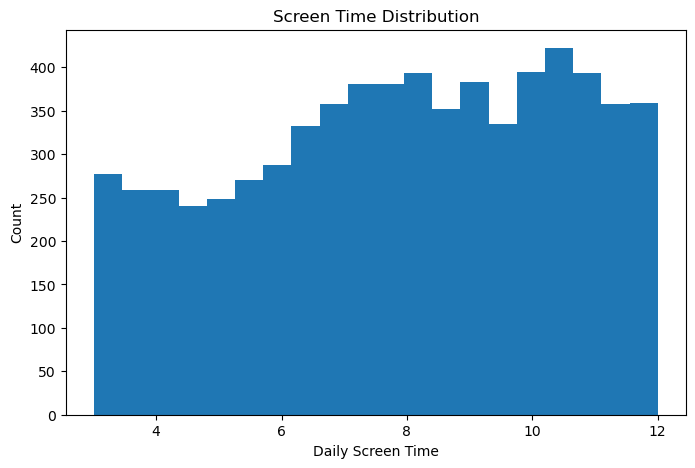

In [13]:
plt.figure(figsize=(8,5))
plt.hist(data['daily_screen_time_hours'], bins=20)
plt.xlabel("Daily Screen Time")
plt.ylabel("Count")
plt.title("Screen Time Distribution")
plt.show()

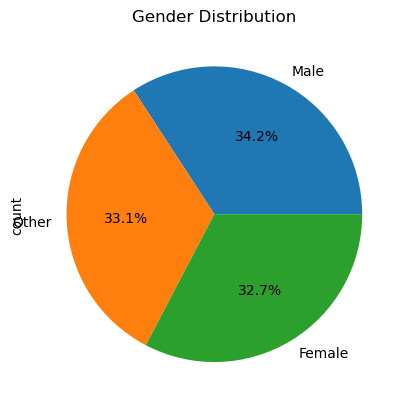

In [14]:
data['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

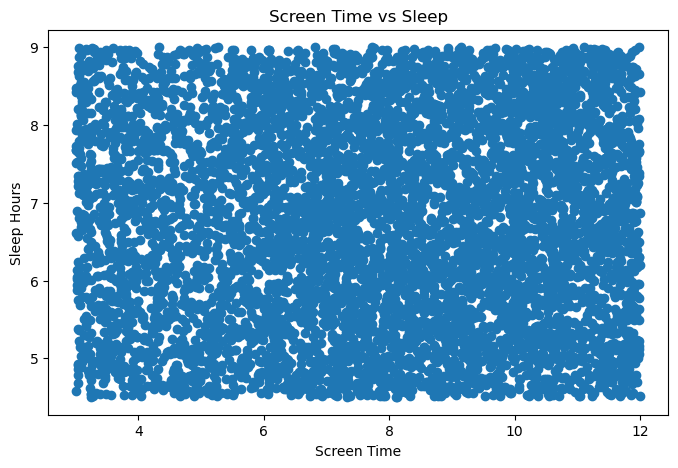

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(data['daily_screen_time_hours'], data['sleep_hours'])
plt.xlabel("Screen Time")
plt.ylabel("Sleep Hours")
plt.title("Screen Time vs Sleep")
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['gender'] = le.fit_transform(data['gender'])

In [20]:
X = data.drop('addicted_label', axis=1)
y = data['addicted_label']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(data.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                       int32
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


In [26]:
data.drop(['transaction_id', 'user_id'], axis=1, inplace=True)

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level'
]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [28]:
print(data.dtypes)

age                          int64
gender                       int64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                 int32
academic_work_impact         int32
addiction_level              int32
addicted_label               int64
dtype: object


In [30]:
X = data.drop('addicted_label', axis=1)
y = data['addicted_label']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

C:\Users\Ganesh bahadur\OneDrive\Attachments\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       265
           1       1.00      1.00      1.00      1072

    accuracy                           1.00      1337
   macro avg       1.00      1.00      1.00      1337
weighted avg       1.00      1.00      1.00      1337



In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

print(importance.sort_values(by='Importance', ascending=False))

                    Feature  Importance
12          addiction_level    9.737445
2   daily_screen_time_hours    1.410362
3        social_media_hours    0.421304
7     notifications_per_day   -0.002802
8         app_opens_per_day   -0.004913
4              gaming_hours   -0.063089
0                       age   -0.063684
10             stress_level   -0.168105
5          work_study_hours   -0.178784
6               sleep_hours   -0.237237
11     academic_work_impact   -0.374494
1                    gender   -0.522017
9       weekend_screen_time   -1.005608


In [37]:
import pickle

pickle.dump(model, open('mobile_addiction_model.pkl', 'wb'))

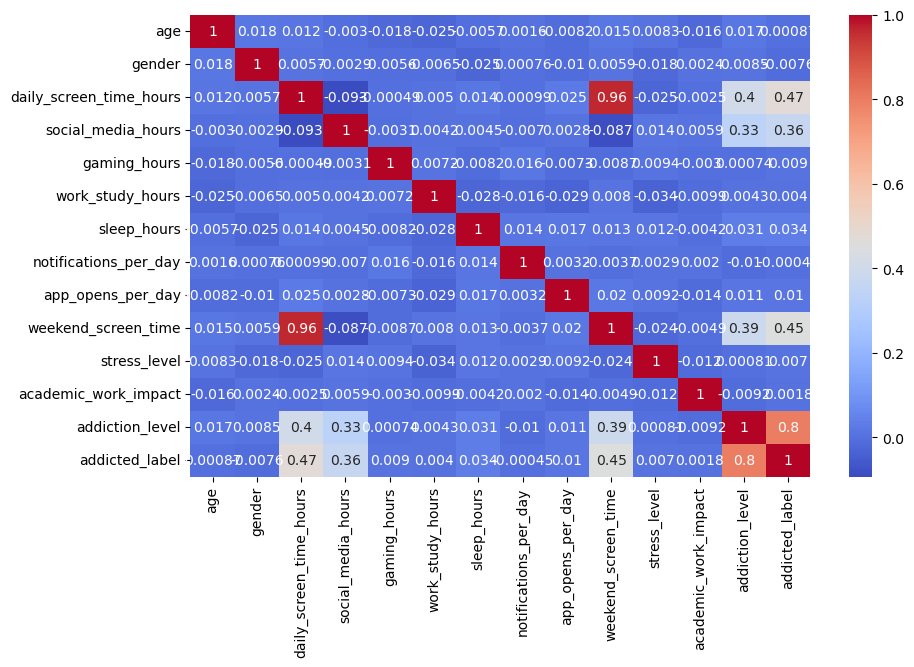

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

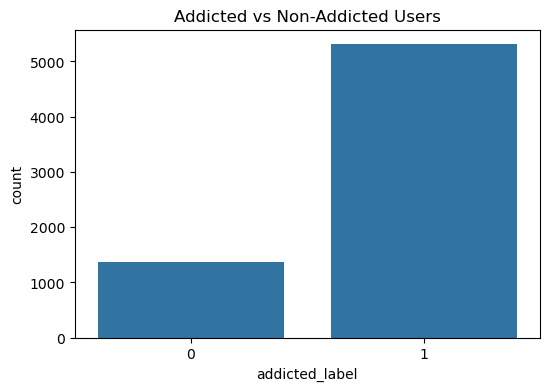

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(x='addicted_label', data=data)

plt.title("Addicted vs Non-Addicted Users")

plt.show()

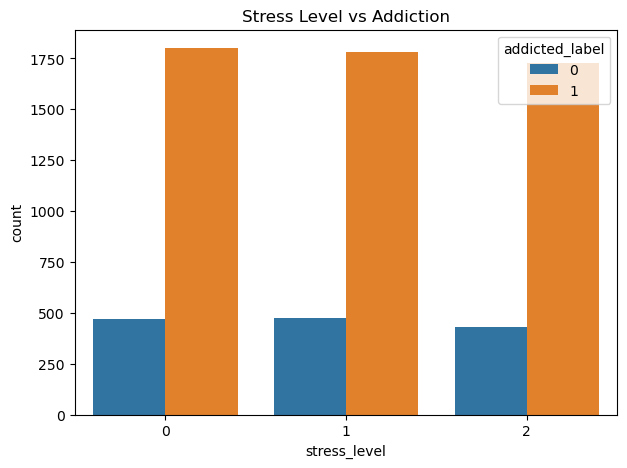

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='stress_level',
    hue='addicted_label',
    data=data
)

plt.title("Stress Level vs Addiction")

plt.show()

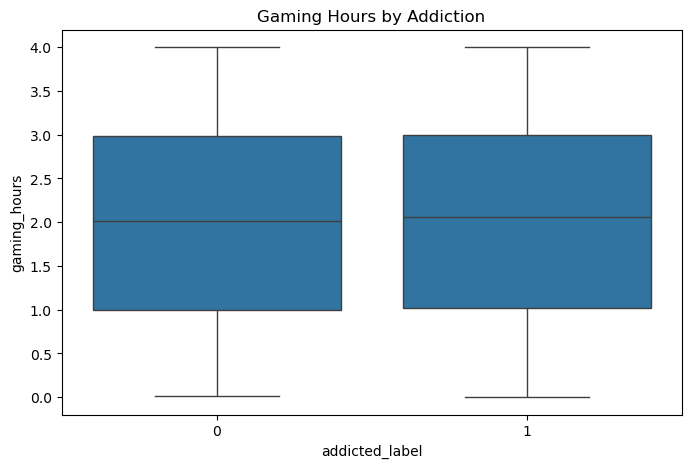

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='addicted_label',
    y='gaming_hours',
    data=data
)

plt.title("Gaming Hours by Addiction")

plt.show()

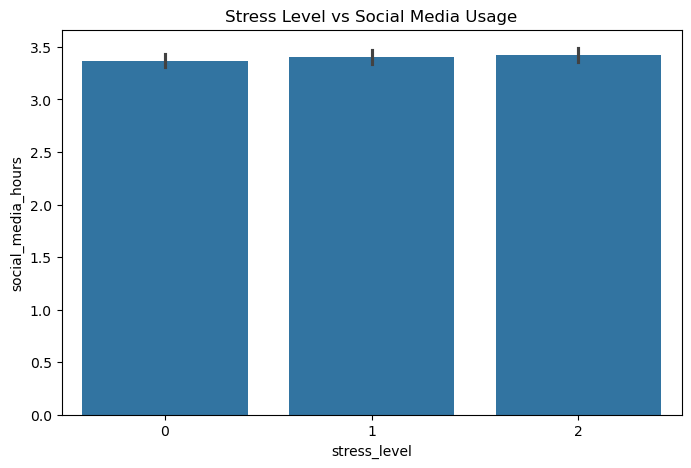

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='stress_level',
    y='social_media_hours',
    data=data
)

plt.title("Stress Level vs Social Media Usage")

plt.show()

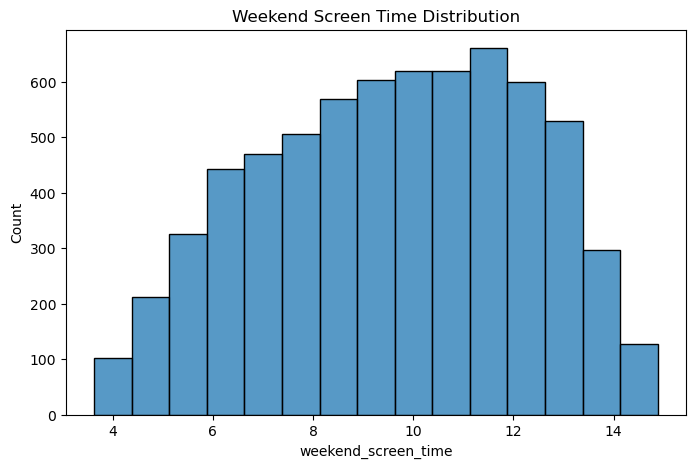

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(data['weekend_screen_time'], bins=15)

plt.title("Weekend Screen Time Distribution")

plt.show()

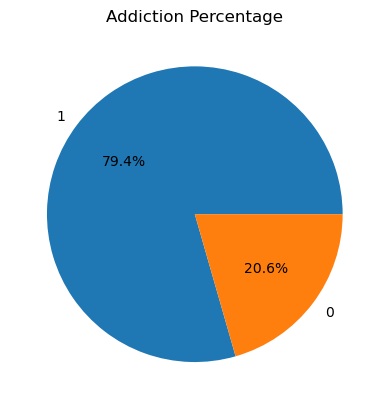

In [48]:
data['addicted_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Addiction Percentage")

plt.ylabel("")

plt.show()

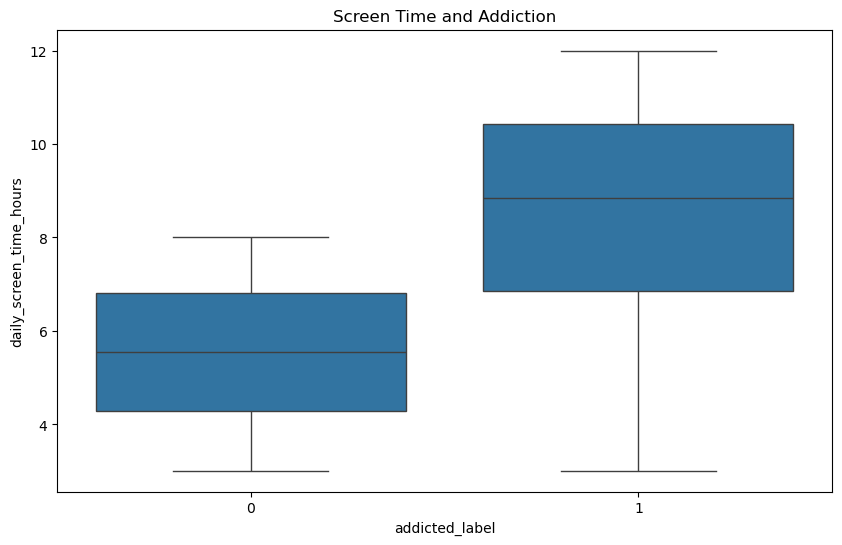

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='addicted_label',
    y='daily_screen_time_hours',
    data=data
)

plt.title("Screen Time and Addiction")

plt.show()

In [51]:
import streamlit as st

st.title("Mobile Addiction Predictor")

screen_time = st.slider("Daily Screen Time", 1, 15)

sleep = st.slider("Sleep Hours", 1, 12)

if st.button("Predict"):
    st.write("High Addiction Risk")

2026-05-18 01:31:27.510 
  command:

    streamlit run C:\Users\Ganesh bahadur\OneDrive\Attachments\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-18 01:31:27.518 Session state does not function when running a script without `streamlit run`
